# XGBoost — Regression (Gradient Boosting with Second-Order Optimization)

---

## 1. Problem Setup

Given a dataset:

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D, \quad y_i \in \mathbb{R}
$$

The goal is to learn a function:

$$
\hat{y}_i = F(x_i)
$$

that minimizes a loss function over all samples.

---

## 2. Model Idea

XGBoost builds an additive model of trees:

$$
F(x) = \sum_{m=1}^{M} \eta \, f_m(x)
$$

where:

- $f_m(x)$ is the $m$-th regression tree  
- $\eta$ is the learning rate  

---

## 3. Initialization

Initial prediction is set to the mean:

$$
F^{(0)}(x_i) = \bar{y} = \frac{1}{N} \sum_{i=1}^{N} y_i
$$

---

## 4. Objective Function

At iteration $m$, the objective is:

$$
\mathcal{L}^{(m)} = \sum_{i=1}^{N} l(y_i, F^{(m-1)}(x_i) + f_m(x_i)) + \Omega(f_m)
$$

where:

- $l(\cdot)$ is the loss function  
- $\Omega(f)$ is the regularization term  

---

## 5. Second-Order Approximation

Using Taylor expansion:

$$
\mathcal{L}^{(m)} \approx \sum_{i=1}^{N} \left[
g_i f_m(x_i) + \frac{1}{2} h_i f_m^2(x_i)
\right] + \Omega(f_m)
$$

where:

$$
g_i = \frac{\partial l(y_i, \hat{y}_i)}{\partial \hat{y}_i}
\quad , \quad
h_i = \frac{\partial^2 l(y_i, \hat{y}_i)}{\partial \hat{y}_i^2}
$$

---

## 6. Loss Functions

### I Mean Squared Error (MSE)

$$
l(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2
$$

$$
g_i = \hat{y}_i - y_i
$$

$$
h_i = 1
$$



### II Huber Loss

For robustness:

$$
g_i =
\begin{cases}
\hat{y}_i - y_i & \text{if } |\hat{y}_i - y_i| \le \delta \\
\delta \cdot \text{sign}(\hat{y}_i - y_i) & \text{otherwise}
\end{cases}
$$

$$
h_i =
\begin{cases}
1 & \text{if } |\hat{y}_i - y_i| \le \delta \\
0 & \text{otherwise}
\end{cases}
$$

---

## 7. Tree Structure

Each tree partitions the input space into regions:

$$
R_1, R_2, \dots, R_T
$$

Each leaf $j$ has a constant weight:

$$
f_m(x) = w_j \quad \text{if } x \in R_j
$$

---

## 8. Leaf Weight Optimization

For a leaf with samples $I_j$:

$$
G_j = \sum_{i \in I_j} g_i
\quad , \quad
H_j = \sum_{i \in I_j} h_i
$$

Optimal leaf weight:

$$
w_j = - \frac{G_j}{H_j + \lambda}
$$

---

## 9. Regularized Objective

The regularization term:

$$
\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$

where:

- $T$ = number of leaves  
- $\gamma$ penalizes number of splits  
- $\lambda$ penalizes large weights  

---

## 10. Split Gain

For a split into left and right nodes:

$$
\text{Gain} =
\frac{1}{2} \left(
\frac{G_L^2}{H_L + \lambda} +
\frac{G_R^2}{H_R + \lambda} -
\frac{G^2}{H + \lambda}
\right) - \gamma
$$

Split is accepted if:

$$
\text{Gain} > 0
$$

---

## 11. Feature Subsampling

A subset of features is selected:

$$
\text{features} \sim \text{Uniform subset of size } \lfloor \text{feature\_fraction} \cdot D \rfloor
$$

This introduces randomness and reduces overfitting.

---

## 12. Tree Growth

At each node:

- Evaluate all candidate splits  
- Select split with maximum gain  

Stopping conditions:

- Maximum depth reached  
- Minimum samples constraint  
- No positive gain  

---

## 13. Additive Model Update

Predictions are updated as:

$$
F^{(m)}(x) = F^{(m-1)}(x) + \eta \, f_m(x)
$$

---

## 14. Final Prediction

After $M$ trees:

$$
F(x) = \sum_{m=1}^{M} \eta \, f_m(x)
$$

---

## 15. Algorithm Summary

For $m = 1$ to $M$:

$$
\text{Compute gradients } g_i \text{ and hessians } h_i
$$

$$
\text{Fit tree } f_m(x) \text{ using } (g_i, h_i)
$$

$$
\text{Update predictions: } F(x) \leftarrow F(x) + \eta f_m(x)
$$

---

## 16. Key Insights

- Uses **second-order optimization** (gradient + hessian)  
- $\lambda$ controls **leaf weight shrinkage**  
- $\gamma$ controls **tree structure complexity**  
- $\eta$ controls **learning speed**  

---

## 17. Intuition

- Each tree fits residual errors  
- Gradients guide direction  
- Hessians control confidence  
- Boosting builds a strong model incrementally  

$$
\text{Final model = sum of weak learners}
$$

In [1]:
class LeafNode:
    """
    A leaf node in the XGBoost tree.

    Attributes:
        weight (float): The optimal leaf weight calculated using 
                        the gradients (G) and hessians (H).
    """
    def __init__(self,weights):
        self.weights = weights

In [2]:
class DecisionNode:
    """
    An intermediate node that splits the data based on a feature threshold.

    Attributes:
        feature (int): The index of the feature used for splitting.
        threshold (float): The value used to divide the data.
        left (Node): The child node for samples where feature <= threshold.
        right (Node): The child node for samples where feature > threshold.
    """
    def __init__(self,feature,threshold,left,right):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

In [3]:
class XGBoostTree:
    """
    A single regression tree built using second-order Taylor expansion.
    
    Attributes:
        max_depth (int): Maximum depth of the tree.
        min_samples_split (int): Minimum samples required to attempt a split.
        feature_fraction (float): Percentage of features to consider per tree.
        gamma (float): Minimum gain required to create a new split.
        lambda_ (float): L2 regularization term on leaf weights.
        root (Node): The root of the trained tree (DecisionNode or LeafNode).
    """
    def __init__(self,max_depth=10,min_samples_split=1,feature_fraction=1,gamma=1,lambda_=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.feature_fraction = feature_fraction
        self.gamma = gamma
        self.lambda_ = lambda_

        # Validate
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.gamma < 0:
            raise ValueError("gamma must be positive")
        if self.lambda_ < 0:
            raise ValueError("lambda must be positive")

        self.root=None
        self.X = None
        self.g = None
        self.h = None

    def _stopping_condition(self,indices,depth):
        """
        Evaluates whether the tree growth should stop at the current node.

        Args:
            indices (np.ndarray): The indices of the samples currently in the node.
            depth (int): The current depth level of the tree.

        Returns:
            bool: True if the node should become a leaf, False otherwise.
        """
        # Depth Constraint: Prevents the tree from becoming too complex and memorizing noise (overfitting).
        if depth >= self.max_depth:
            return True
        # Sample Size Constraint: Ensures there is enough statistical evidence to justify another split.
        if len(indices) < self.min_samples_split:
            return True
        # 3. Purity Check: If all remaining samples have the same gradient/hessian, no further gain can be achieved.
        if len(np.unique(self.g[indices])) <= 1:
             return True
        return False

    def _feature_sampling(self):
        """
        Performs column subsampling (Feature Fraction). 
        
        Randomly selects a subset of features to consider for the current node. 
        This reduces the variance of the model and prevents dominant features 
        from over-structuring every tree.

        Returns:
            np.ndarray: An array of randomly selected feature indices.
        """
        # Calculate how many features to select based on feature_fraction
        num_sampled_features = max(1,int(round(self.feature_fraction * self.num_features)))
        # Randomly choose indices without replacement
        sampled_features = np.random.choice(self.num_features,num_sampled_features,replace=False)
        return sampled_features

    def _find_all_thresholds(self,sampled_features,indices):
        """
        Identifies potential split points for each sampled feature. 
        
        Instead of testing every unique value, it calculates the midpoints 
        between sorted unique values to find the most balanced thresholds.

        Args:
            sampled_features (np.ndarray): Indices of features to evaluate.
            indices (np.ndarray): Indices of the samples in the current node.

        Returns:
            list: A list of numpy arrays, where each array contains the 
                  candidate thresholds for a specific feature.
        """
        all_thresholds = []
        for feature in sampled_features:
            # Get unique values for the specific feature among the current samples
            unique_vals = np.unique(self.X[indices,feature])
            # No possible split if all values are the same
            if len(unique_vals)==1:
                all_thresholds.append(np.array([]))
            else:
                # Calculate midpoints between adjacent sorted values
                averages = (unique_vals[1:] + unique_vals[:-1])/2
                all_thresholds.append(averages)

        return all_thresholds

    def _leaf_weight(self,G,H):
        """
        Calculates the optimal weight (prediction value) for a leaf node.
        
        The weight is derived by setting the derivative of the objective 
        function to zero, including L2 regularization (lambda).
        
        Formula: w = -G / (H + lambda)

        Args:
            G (float): Sum of gradients in the leaf.
            H (float): Sum of hessians in the leaf.

        Returns:
            float: The calculated leaf weight.
        """
        # Numerical stability to prevent division by zero
        eps=1e-10
        weight = -G/(H+self.lambda_ + eps)
        return weight

    def _computeGH(self,indices):
        """
        Aggregates the gradients (g) and hessians (h) for a specific 
        subset of data points.

        Args:
            indices (np.ndarray): Indices of the samples in the current node.

        Returns:
            tuple: (Sum of Gradients, Sum of Hessians)
        """
        G = np.sum(self.g[indices])
        H = np.sum(self.h[indices])

        return G,H

    def _local_gain(self,G,H):
        """
        Calculates the structure score for a specific node (or candidate leaf).
        
        The score represents how much the loss is reduced by the current 
        sum of gradients and hessians.
        
        Formula: Gain_node = G^2 / (H + lambda)

        Args:
            G (float): Sum of gradients in the node.
            H (float): Sum of hessians in the node.

        Returns:
            float: The structure score for this node.
        """
        # Numerical stability
        eps = 1e-10
        return G**2/(H + self.lambda_ + eps)

    def _compute_score(self,left_gain,right_gain,node_gain):
        """
        Calculates the total gain of a potential split. 
        
        This is the core "Split Criterion" for XGBoost. It compares the scores 
        of the two new child nodes against the score of the original parent node, 
        penalizing for complexity using gamma.
        
        Formula: 0.5 * (Gain_L + Gain_R - Gain_parent) - gamma

        Args:
            left_gain (float): Score of the potential left child.
            right_gain (float): Score of the potential right child.
            node_gain (float): Score of the parent node before splitting.

        Returns:
            float: The net gain. If negative, the split is usually rejected.
        """
        return 0.5*(left_gain+right_gain-node_gain) - self.gamma

    def _split(self,feature,indices,threshold):
        """
        Partitions the current sample indices into left and right groups 
        based on a feature threshold.

        Args:
            feature (int): The index of the feature to split on.
            indices (np.ndarray): Current sample indices in the node.
            threshold (float): The value to compare against.

        Returns:
            tuple: (left_indices, right_indices)
        """
        condition = self.X[indices,feature] <= threshold
        return indices[condition] , indices[~condition]

    def _find_best_feature_threshold_score(self,sampled_features,all_thresholds,indices):
        """
        Greedily searches for the best feature and threshold to split the data.
        
        This method iterates through all sampled features and their candidate 
        thresholds, calculates the resulting Gain for each, and tracks the 
        one that provides the highest score.

        Args:
            sampled_features (np.ndarray): Indices of features to evaluate.
            all_thresholds (list): List of candidate threshold arrays for each feature.
            indices (np.ndarray): Current sample indices in the node.

        Returns:
            tuple: (best_feature, best_threshold, best_score)
                - best_feature: Index of the feature that yielded the highest gain.
                - best_threshold: The value to split on.
                - best_score: The highest gain achieved (must be > 0 to split).
        """
        best_score = -np.inf
        best_feature = None
        best_threshold = None
        # Calculate parent node statistics once to compare against children
        G_node , H_node = self._computeGH(indices)
        node_gain = self._local_gain(G_node , H_node)

        for i,feature in enumerate(sampled_features):
            threshold_for_current_feature = all_thresholds[i]
            feature_mask = self.X[indices,feature]

            if len(threshold_for_current_feature)==0:
                continue
            for threshold in threshold_for_current_feature:
                # Partition indices based on current threshold
                condition = feature_mask<=threshold
                left_indices , right_indices = indices[condition], indices[~condition]
                # Skip split if it results in an empty child
                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue
                # Compute stats and gain for this specific split
                G_L , H_L = self._computeGH(left_indices)
                G_R , H_R = self._computeGH(right_indices)
                left_gain , right_gain = self._local_gain(G_L , H_L) , self._local_gain(G_R , H_R)
                # Calculate net gain (Total Children Gain - Parent Gain - Gamma)
                score = self._compute_score(left_gain , right_gain,node_gain)
                # Track the best candidate
                if score > best_score:
                    best_score=score
                    best_threshold = threshold
                    best_feature = feature


        return best_feature,best_threshold,best_score


    def _find_best_split(self,indices):
        # Sample features (Feature Subsampling)
        sampled_features = self._feature_sampling()
        all_thresholds = self._find_all_thresholds(sampled_features,indices)
        best_feature,best_threshold,best_score =  self._find_best_feature_threshold_score(sampled_features,all_thresholds,indices)

        return best_feature,best_threshold,best_score

    def _build_tree(self,indices,depth):
        """
        Recursive function to grow the tree.
        """
        G , H = self._computeGH(indices)
        # Check stopping conditions
        if self._stopping_condition(indices,depth):
            return LeafNode(self._leaf_weight(G,H))
            
        # Find the best split
        best_feature,best_threshold,best_score = self._find_best_split(indices)

        if best_score <=0:
            return LeafNode(self._leaf_weight(G,H))

        left_indices , right_indices = self._split(best_feature,indices,best_threshold)

        if len(left_indices)==0 or len(right_indices)==0:
            return LeafNode(self._leaf_weight(G,H))

        left_child = self._build_tree(left_indices,depth+1)
        right_child = self._build_tree(right_indices,depth+1)

        return DecisionNode(best_feature, best_threshold, left_child, right_child)

    def fit(self,X,g,h):
        """
        Builds the tree by recursively finding the best splits.

        Args:
            X (np.ndarray): Feature matrix.
            g (np.ndarray): Gradients of the loss function.
            h (np.ndarray): Hessians of the loss function.
        """
        X = np.asarray(X)
        g = np.asarray(g)
        h = np.asarray(h)

        self.X = X
        self.g = g
        self.h = h

        N , self.num_features = self.X.shape
        indices = np.arange(N)

        self.root = self._build_tree(indices,0)

    def _predict_single(self,x,node):
        """
        Traverses the tree to find the leaf weight for a single sample.
        """
        if isinstance(node,LeafNode):
            return node.weights
        else:
            if x[node.feature] <= node.threshold:
                return self._predict_single(x,node.left)
            else:
                return self._predict_single(x,node.right)

    def predict(self,X):
        """
        Predicts the output for each sample in X.
        """
        y_pred = np.array([self._predict_single(x,self.root) for x in X])
        return y_pred

    def _count_leaves(self,node):
        """
        Recursively counts the total number of terminal (leaf) nodes in the tree.
        
        Args:
            node (Node): The starting node (root).
            
        Returns:
            int: Total count of leaf nodes.
        """
        if isinstance(node,LeafNode):
            return 1
        else :
            return self._count_leaves(node.left) + self._count_leaves(node.right)

    def _unique_weights(self, node):
        """
        Traverses the tree to collect all predicted leaf weights. 
        Useful for analyzing weight distribution and shrinkage.
        
        Args:
            node (Node): The starting node (root).
            
        Returns:
            list: A list of all floating-point weights stored in the leaves.
        """
        if isinstance(node, LeafNode):
            return [node.weights]
        # Combine weights from left and right branches
        return self._unique_weights(node.left) + self._unique_weights(node.right)

In [4]:
class XGBoostRegressor:
    """
    An ensemble regressor that uses Gradient Boosting with second-order Taylor expansion.
    
    This class manages the lifecycle of the boosting process: initializing the 
    base prediction, calculating loss-specific gradients/hessians, and 
    aggregating individual tree predictions into a final model.

    Attributes:
        n_estimators (int): The number of boosting iterations (number of trees).
        max_depth (int): Maximum depth allowed for each individual tree.
        min_samples_split (int): Minimum samples required in a node to split.
        feature_fraction (float): Subsampling ratio of features per tree [0.0, 1.0].
        gamma (float): Minimum gain required to split a node (L1-style pruning).
        lambda_ (float): L2 regularization term on leaf weights.
        learning_rate (float): Shrinkage factor (eta) applied to each tree's update.
        loss_function (str): The optimization objective ('mse' or 'huber').
        delta (float): The threshold for Huber loss (only used if loss_function='huber').
        random_state (int): Seed for reproducibility in feature subsampling.
        all_models (list): A collection of trained XGBoostTree objects.
    """
    def __init__(self,n_estimators = 100,max_depth=10,min_samples_split=1,feature_fraction=1,gamma=1,lambda_=1,
                learning_rate=0.01,loss_function='mse',delta=1,random_state=123):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split=min_samples_split
        self.feature_fraction = feature_fraction
        self.gamma = gamma
        self.lambda_ = lambda_
        self.learning_rate = learning_rate
        self.loss_function = loss_function
        self.delta = delta
        self.random_state = random_state

         # Validate
        if type(self.n_estimators) != int or self.n_estimators <= 0:
            raise ValueError('N estimators must be a positive integer')
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.gamma < 0:
            raise ValueError("gamma must be positive")
        if self.lambda_ < 0:
            raise ValueError("lambda must be positive")
        if self.learning_rate <= 0:
            raise ValueError("learning rate must be positive")
        if self.loss_function not in ['mse','huber']:
            raise ValueError("loss function can be either 'mse' or 'huber'")
        if self.delta <= 0:
            raise ValueError("delta must be positive")
  
        self.all_models = None

    def _gradient_hessian(self,y,y_hat):
        """
        Calculates the first and second order derivatives of the loss function.
        
        The gradient (g) represents the direction and magnitude of the error, 
        while the hessian (h) represents the curvature or confidence.

        Args:
            y (np.ndarray): The ground truth target values.
            y_hat (np.ndarray): The current cumulative predictions of the ensemble.

        Returns:
            tuple: (g, h)
                - g (np.ndarray): Gradient vector.
                - h (np.ndarray): Hessian vector.
        """
        residual = y_hat - y
        # Mean Squared Error: L = 0.5 * (y - y_hat)^2
        if self.loss_function == 'mse':
            # g = dL/dy_hat = (y_hat - y)
            g = residual
            # h = d^2L/dy_hat^2 = 1
            h = np.ones_like(y, dtype=float)
        # Huber Loss: Robust to outliers by using linear loss for large residuals
        elif self.loss_function == 'huber':
            condition = np.abs(residual) <= self.delta
            # Quadratic behavior for small errors
            # Linear behavior for large errors (derivative becomes constant delta)
            g = np.where(condition, residual, self.delta * np.sign(residual))
            # To ensure the tree logic (G^2/(H+lambda)) doesn't fail, use a small epsilon for the hessian where the loss is linear.
            g = np.clip(g, -self.delta, self.delta)
            h = np.where(condition, 1.0, 1e-10)
        return g,h

    def fit(self,X,y):
        """
        Trains the ensemble of XGBoost trees using the Gradient Boosting algorithm.
        
        This method initializes the model predictions and iteratively adds trees 
        that minimize the loss function through second-order Taylor expansion.

        Args:
            X (np.ndarray or pd.DataFrame): The training input samples.
            y (np.ndarray or pd.Series): The target values (real numbers).
            
        Side Effects:
            Populates self.all_models with trained XGBoostTree instances.
        """
        # Ensure inputs are in a consistent numpy format
        X = np.asarray(X)
        y = np.asarray(y)
        # Reshape X to 2D if a single feature is passed
        if X.ndim==1:
            X = X.reshape(-1,1)

        y = y.reshape(-1)
        
        n_samples = len(X)

        # Initial prediction: The simplest model is the mean of the targets
        self.initial_prediction = np.mean(y)
        y_hat = np.full(n_samples,self.initial_prediction)
    
        self.all_models =[]

        np.random.seed(self.random_state)

        # Iterative Boosting
        for i in range(self.n_estimators):
            # Calculate derivatives for the current state of the ensemble
            gradient , hessian = self._gradient_hessian(y,y_hat)
            # Initialize a new tree with the regressor's hyperparameters
            model = XGBoostTree(max_depth=self.max_depth,min_samples_split=self.min_samples_split,
                                feature_fraction=self.feature_fraction,gamma=self.gamma ,lambda_=self.lambda_)
            # Fit the tree to the gradients and hessians (not the raw 'y')
            model.fit(X,gradient , hessian)
            y_pred = model.predict(X)

            # Update the ensemble prediction: y_hat = y_hat + (learning_rate * tree_prediction)
            y_hat += self.learning_rate * y_pred
            # Store the tree for future inference
            self.all_models.append(model)

    def predict(self,X):
        """
        Generates final predictions for the input data by aggregating 
        the results of all trees in the ensemble.

        The final prediction is calculated as:
        y_final = Initial_Mean + sum(learning_rate * tree_i.predict(X))

        Args:
            X (np.ndarray or pd.DataFrame): The input samples to predict.

        Returns:
            np.ndarray: Predicted values for each sample.
        """
        # Ensure X is the correct shape
        y_pred = np.full(X.shape[0], self.initial_prediction)
        # Initialize predictions with the base learner value (the mean of training y)
        for model in self.all_models:
            # Add the weighted correction from each tree
            y_pred += self.learning_rate *model.predict(X)
        return y_pred    

# Effect of $\lambda$ (L2 Regularization) on Leaf Weights

---

## 1. Objective

The goal is to study how the regularization parameter $\lambda$ affects the magnitude of leaf weights in XGBoost.

---

## 2. Setup

We train an XGBoost regressor on a simple synthetic dataset and vary:

$$
\lambda \in \{0, 10, 20, 50, 125, 150, 200\}
$$

For each value of $\lambda$:

- Train the model
- Extract leaf weights from the final tree
- Compute the mean absolute value of weights

---

## 3. Key Formula

The optimal leaf weight in XGBoost is given by:

$$
w_j = -\frac{G_j}{H_j + \lambda}
$$

where:

- $G_j = \sum_{i \in R_j} g_i$ is the sum of gradients  
- $H_j = \sum_{i \in R_j} h_i$ is the sum of hessians  
- $\lambda$ is the L2 regularization parameter  

---

## 4. Expected Result

From the formula:

$$
\lambda \uparrow \;\Rightarrow\; H_j + \lambda \uparrow \;\Rightarrow\; |w_j| \downarrow
$$

This implies:

- Increasing $\lambda$ reduces the magnitude of leaf weights  
- The model becomes smoother and less sensitive to noise  

---



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
def generate_data(n_samples=1000, noise=0.2, random_state=42):
    np.random.seed(random_state)
    
    # Generate features
    X = np.random.randn(n_samples, 2)
    
    # Linear boundary
    y = (X[:, 0] + X[:, 1] > 0).astype(int)
    
    # Add noise
    X += noise * np.random.randn(*X.shape)
    
    return X, y

X, y = generate_data()

In [6]:
# Setup
lambdas = [0, 10 , 20, 50, 75, 125, 150, 200]

summary_stats = []

# Run 
for lam in lambdas:
    
    model = XGBoostRegressor(
        n_estimators=10,
        max_depth=1,
        learning_rate=0.01,
        gamma=0,
        lambda_=lam,
        feature_fraction=1,
        random_state=42,
    )
    
    model.fit(X, y)
    
    # Collect weights from LAST tree
    last_tree = model.all_models[-1]
    weights = last_tree._unique_weights(last_tree.root)
    
    weights = np.array(weights)
    # Summary stats
    summary_stats.append({
        "lambda": lam,
        "mean_abs_weight": np.mean(np.abs(weights))
    })

In [7]:
# DataFrame
summary_df = pd.DataFrame(summary_stats)

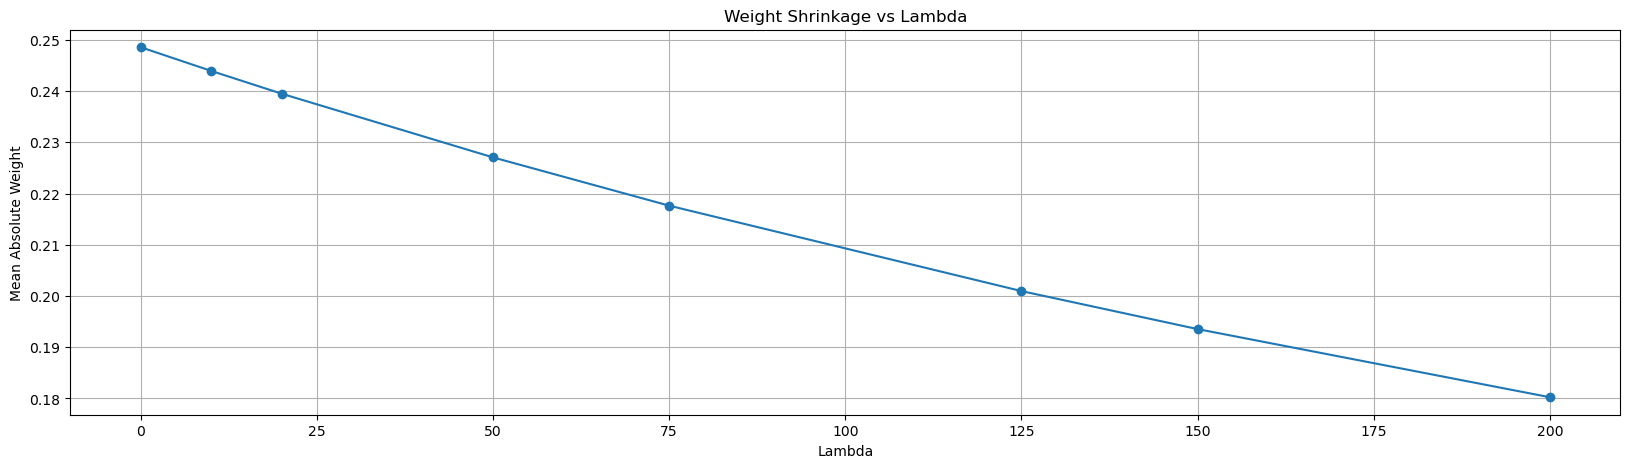

In [8]:
# 7. Plot Mean |Weight| vs Lambda
plt.figure(figsize=(20,5))

plt.plot(summary_df["lambda"], summary_df["mean_abs_weight"], marker='o')
plt.xlabel("Lambda")
plt.ylabel("Mean Absolute Weight")
plt.title("Weight Shrinkage vs Lambda")
plt.grid(True)

plt.show()

## 5. Observations

From the plot of mean absolute weight vs $\lambda$:

- When $\lambda$ is small:
  - Leaf weights have larger magnitudes  
  - Model makes stronger corrections  

- As $\lambda$ increases:
  - Leaf weights shrink toward zero  
  - Updates become more conservative  

---

## 6. Interpretation

- Small $\lambda$:
  - Low regularization  
  - High variance  
  - Risk of overfitting  

- Large $\lambda$:
  - Strong regularization  
  - Low variance  
  - Risk of underfitting  

---

## 7. Important

$$
\text{Leaf weights directly control model updates}
$$

$$
\lambda \text{ controls how aggressive those updates are}
$$

---

## 8. Conclusion

This shows that $\lambda$ acts as a shrinkage factor on leaf weights, controlling model complexity and stability. Increasing $\lambda$ leads to smaller, more stable updates, improving generalization at the cost of reduced flexibility.

---